In [16]:
# Essentail Imports for Pytorch Dataloader

#Essentails
import os
import json
from PIL import Image
from matplotlib import pyplot as plt

#pytorch imports
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms


In [17]:
#print paths:
#os.listdir('../data')

with open('../data/instances_train2019.json', 'r') as f:
    temp_data = json.load(f)

temp_data['annotations'][0]

{'area': 111763.29,
 'bbox': [1188.4, 1052.45, 390.96, 285.87],
 'category_id': 112,
 'id': 0,
 'image_id': 0,
 'iscrowd': 0,
 'segmentation': [[]],
 'point_xy': [1383.88, 1195.38]}

### Custom DataSet Class (Normal Transformers)

In [18]:
# Define the custom dataset class
class CustomDatasetClass(Dataset):
    '''
    '''

    #Init function.
    def __init__(self,images_dir, json_path, transforms=None):
        self.images_dir = images_dir
        self.transforms = transforms

        # Load the JSON file:
        with open(json_path, 'r') as f:
            data = json.load(f)
        
        self.images = data['images']
        self.annotations = data['annotations']
        self.categories = data['categories']


        #pre-map the annotation to image_ID for faster access later O(n) instead of looping later:

        ''' Annotation Structure for an image
        {'area': 111763.29,
        'bbox': [1188.4, 1052.45, 390.96, 285.87],
        'category_id': 112,
        'id': 0,
        'image_id': 0,
        'iscrowd': 0,
        'segmentation': [[]],
        'point_xy': [1383.88, 1195.38]}
        '''

        self.img_to_anns = {}
        for ann in self.annotations:
            img_id = ann['image_id']

            if img_id not in self.img_to_anns:
                self.img_to_anns[img_id] = []
            self.img_to_anns[img_id].append(ann)
            

    #len function:
    def __len__(self):
        return len(self.images)

    #getitem function:,
    def __getitem__(self,idx):
        img_info = self.images[idx] # Image entries: {'file_name': '038900004095_camera0-13.jpg', 'width': 2592, 'height': 1944, 'id': 0}
        img_id = img_info['id']

        img_name = img_info['file_name']

        full_path = os.path.join(self.images_dir, img_name)

        image = Image.open(full_path).convert('RGB')


        #Now we got the image and opened it. time to extract the features (annotations):
        #retrieve the pre-stored anns
        anns = self.img_to_anns.get(img_id, [])

        boxes,labels = [],[]

        for ann in anns:
            #convert COCO to Pytorch: [x,y,w,h] -> [x1,y1,x2,y2]

            x,y,w,h = ann['bbox']
            boxes.append([x, y, (x+w), (y+h)])
            labels.append(ann['category_id'])


        #convert EVERYTHING to Tensors:
        target = {
            'boxes': torch.as_tensor(boxes, dtype=torch.float32),
            'labels': torch.as_tensor(labels, dtype=torch.int64),
            'image_id': torch.tensor([img_id])
        }

        # Apply transformations
        if self.transforms:
            # For detection, transforms often need both image and target
            image, target = self.transforms(image, target)

        return image, target



In [19]:
# Define paths for clarity
DATA_ROOT = "../data/"

# Create instances for each split
train_dataset = CustomDatasetClass(
    images_dir=os.path.join(DATA_ROOT, "train2019"),
    json_path=os.path.join(DATA_ROOT, "instances_train2019.json"),
)

val_dataset = CustomDatasetClass(
    images_dir=os.path.join(DATA_ROOT, "val2019"),
    json_path=os.path.join(DATA_ROOT, "instances_val2019.json")
)

test_dataset = CustomDatasetClass(
    images_dir = os.path.join(DATA_ROOT, 'test2019'),
    json_path = os.path.join(DATA_ROOT, 'instances_test2019.json')
)

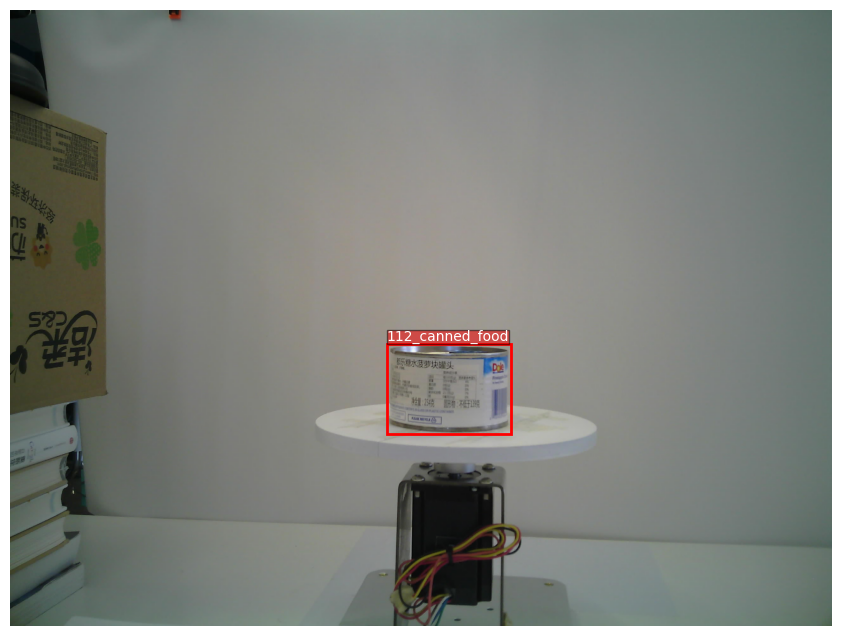

In [20]:
# 1. تجهيز القاموس باستخدام self.categories الجديد
id_to_name = {cat['id']: cat['name'] for cat in train_dataset.categories}

# 2. استخراج عينة
img, tar = train_dataset[0]

# 3. دالة الرسم (تأكد من عمل import لـ matplotlib.patches)
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def visualize_sample_pro(image, target, id_map):
    fig, ax = plt.subplots(1, figsize=(12, 8))
    
    # تحويل من Tensor إلى Numpy Array للرسم
    if torch.is_tensor(image):
        # PIL Images are already HWC, Tensors are CHW
        # if you didn't apply ToTensor yet, it might stay as PIL
        import numpy as np
        image = np.array(image)
    
    ax.imshow(image)
    
    boxes = target['boxes']
    labels = target['labels']
    
    for box, label in zip(boxes, labels):
        x1, y1, x2, y2 = box.tolist() # تحويل لـ list عشان نطلع الأرقام
        width, height = x2 - x1, y2 - y1
        
        class_name = id_map.get(label.item(), f"ID: {label.item()}")
        
        rect = patches.Rectangle((x1, y1), width, height, linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, y1, class_name, color='white', verticalalignment='bottom',
                bbox={'facecolor': 'red', 'alpha': 0.5, 'pad': 0})
    
    plt.axis('off')
    plt.show()

visualize_sample_pro(img, tar, id_to_name)

### Custom Dataset Class with Test Time Augmentation 'TTA' using (Albeumintation)

In [21]:
#Augmentation imports
import numpy as np
import albumentations as A #Main Augmentations Library
from albumentations.pytorch import ToTensorV2

# Define the custom dataset class
class CustomAugmentationClass(Dataset):
    '''
    '''

    #Init function.
    def __init__(self,images_dir, json_path, transforms=None):
        self.images_dir = images_dir
        self.transforms = transforms

        # Load the JSON file:
        with open(json_path, 'r') as f:
            data = json.load(f)
        
        self.images = data['images']
        self.annotations = data['annotations']
        self.categories = data['categories']


        #pre-map the annotation to image_ID for faster access later O(n) instead of looping later:

        ''' Annotation Structure for an image
        {'area': 111763.29,
        'bbox': [1188.4, 1052.45, 390.96, 285.87],
        'category_id': 112,
        'id': 0,
        'image_id': 0,
        'iscrowd': 0,
        'segmentation': [[]],
        'point_xy': [1383.88, 1195.38]}
        '''

        self.img_to_anns = {}
        for ann in self.annotations:
            img_id = ann['image_id']

            if img_id not in self.img_to_anns:
                self.img_to_anns[img_id] = []
            self.img_to_anns[img_id].append(ann)
            

    #len function:
    def __len__(self):
        return len(self.images)

    #getitem function:
    def __getitem__(self,idx):
        img_info = self.images[idx] # Image entries: {'file_name': '038900004095_camera0-13.jpg', 'width': 2592, 'height': 1944, 'id': 0}
        img_id = img_info['id']

        img_name = img_info['file_name']

        full_path = os.path.join(self.images_dir, img_name)

        #1- Albumentations only accepts numpy arrays
        image = Image.open(full_path).convert('RGB')
        image = np.array(image)

        #2- time to extract the features (annotations):

        #retrieve the pre-stored anns
        anns = self.img_to_anns.get(img_id, [])

        boxes,labels = [],[]

        for ann in anns:
            #convert COCO to Pytorch: [x,y,w,h] -> [x1,y1,x2,y2]

            x,y,w,h = ann['bbox']
            boxes.append([x, y, (x+w), (y+h)])
            labels.append(ann['category_id'])

        #3- apply transformations with Albumentations.
        if self.transforms:
            transformed = self.transforms(image=image, bboxes=boxes, category_ids=labels)
            image = transformed['image']
            boxes = transformed['bboxes']
            labels = transformed['category_ids']



        #4- convert EVERYTHING to Tensors (after Transformation)
        #and handle empty boxes just in case:
        if len(boxes) > 0:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)
        else:
            boxes = torch.zeros((0,4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)

        
        #5- Define target (as a Dictionary !!!)
        target = {
            'boxes':boxes,
            'labels':labels,
            'image_id':torch.tensor([img_id])
        }


        return image, target
 

In [ ]:
#Transforms
train_transformers = A.Compose([
    A.Resize(640,640),
    A.HorizontalFlip(p=0.3),
    A.GaussianBlur(blur_limit=3, p=1.0),
    A.RandomRotate90(p=0.2),
    A.ColorJitter(p=0.2),
    A.SaltAndPepper(amount=(0.5, 0.2), p=0.2),
    A.CoarseDropout(max_holes=8, max_height=64, max_width=64, p=0.1),
    ToTensorV2()
], 
bbox_params=A.BboxParams(coord_format='pascal_voc', label_fields=['category_ids'])
)

val_test_transformers = A.Compose([
    A.Resize(640, 640),
    ToTensorV2()
], bbox_params=A.BboxParams(coord_format='pascal_voc', label_fields=['category_ids'])
)


# Create Datasets
train_dataset = CustomAugmentationClass(
    images_dir=os.path.join(DATA_ROOT, "train2019"),
    json_path=os.path.join(DATA_ROOT, "instances_train2019.json"),
    transforms=train_transformers
)

val_dataset = CustomAugmentationClass(
    images_dir=os.path.join(DATA_ROOT, "val2019"),
    json_path=os.path.join(DATA_ROOT, "instances_val2019.json"),
    transforms=val_test_transformers
)

test_dataset = CustomAugmentationClass(
    images_dir=os.path.join(DATA_ROOT, "test2019"),
    json_path=os.path.join(DATA_ROOT, "instances_test2019.json"),
    transforms=val_test_transformers
)


/tmp/ipykernel_11199/218374199.py:9: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=64, max_width=64, p=0.1),


#### Train& Test dataset Visualization

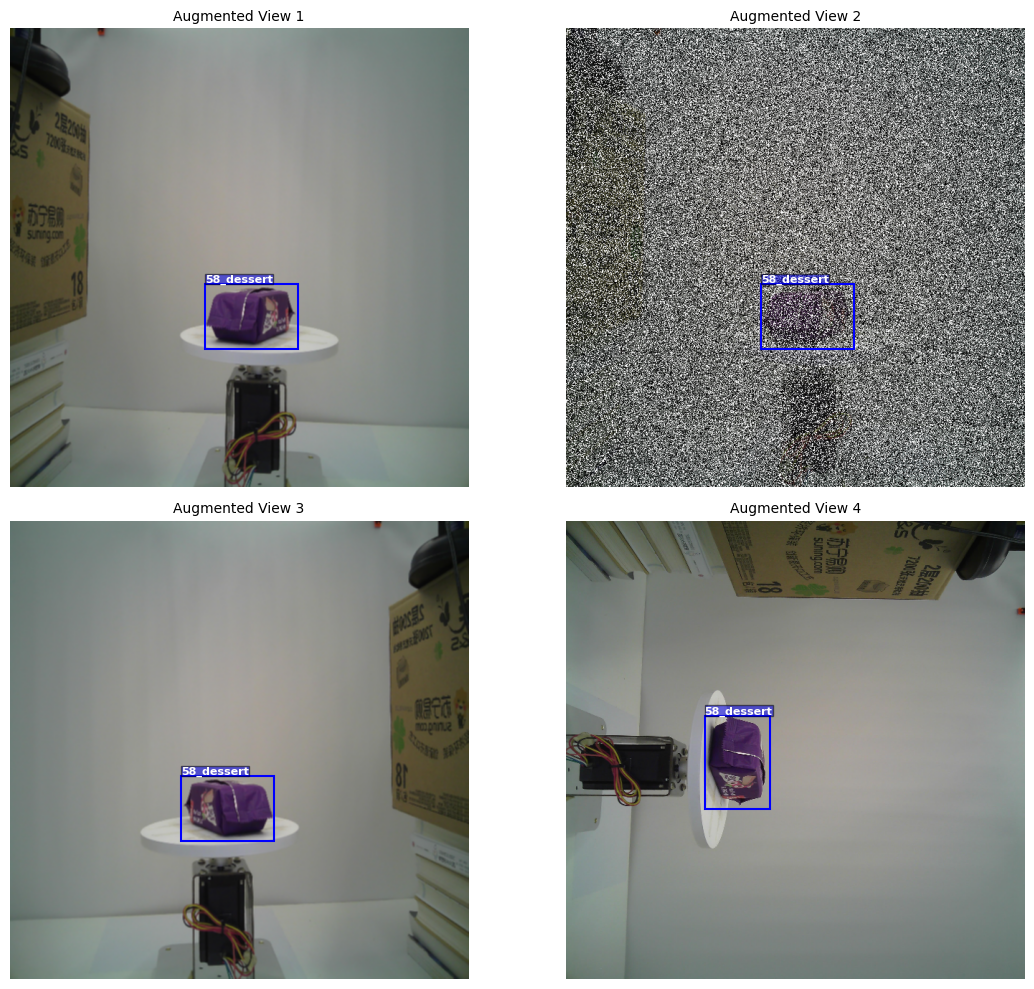

In [24]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random 

#Draw 4 random samples from the dataset with their boxes:

#create the plot: 
fig, axes = plt.subplots(2,2,figsize=(12,10))
axes = axes.flatten() #to loop easily in 1D

random_index = random.randint(0,len(train_dataset)-1)
for i in range(4):
    #pick a random sample:
    img,target = train_dataset[random_index]

    #convert from tensor to numpy for plotting:
    plot_img = img.permute(1,2,0).numpy()

    axes[i].imshow(plot_img)

    #draw the boxes/labels for the specific sample:
    boxes = target['boxes']
    labels = target['labels']

    for box, label in zip(boxes, labels):
        x1, y1, x2, y2 = box.tolist()
        width, height = x2 - x1, y2 - y1

        # 1. Draw the Rectangle
        rect = patches.Rectangle(xy=(x1, y1), width=width, height=height, 
                                 linewidth=1.5, edgecolor='blue', facecolor='none')
        axes[i].add_patch(rect)

        # 2. Get the actual name using the ID (using id_to_name dictionary)
        class_id = label.item() # Convert tensor to int
        class_name = id_to_name.get(class_id, f"ID: {class_id}")

        # 3. Add the text label
        # We put it at (x1, y1) which is the top-left corner
        axes[i].text(x=x1, y=y1, s=class_name, 
                     color='white', fontsize=8, fontweight='bold',
                     va='bottom', ha='left', # 'bottom' makes it sit ON the line
                     bbox=dict(facecolor='blue', alpha=0.5, pad=0)) # Added a small background for readability

    axes[i].set_title(f"Augmented View {i+1}", fontsize=10)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

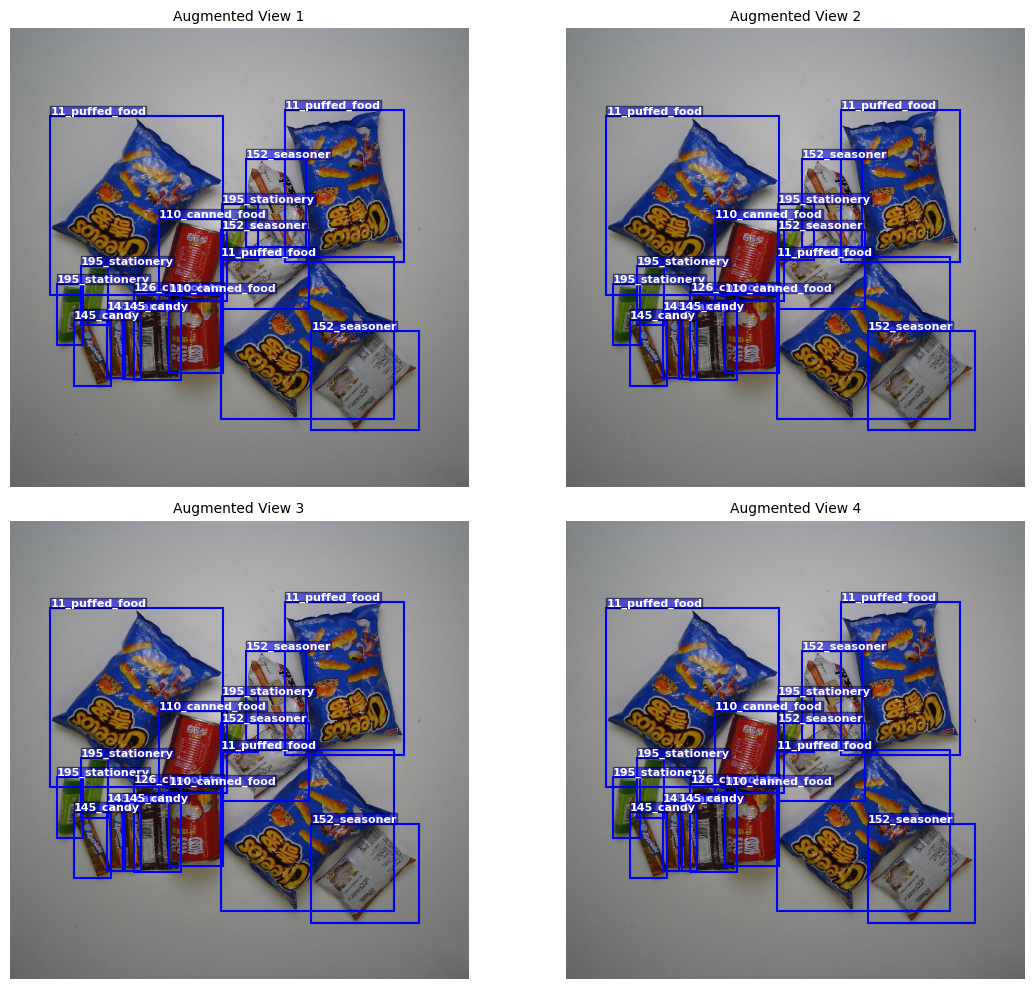

In [41]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random 

#Draw 4 random samples from the val dataset with their boxes:

#create the plot: 
fig, axes = plt.subplots(2,2,figsize=(12,10))
axes = axes.flatten() #to loop easily in 1D

random_index = random.randint(0,len(test_dataset)-1)
for i in range(4):
    #pick a random sample:
    img,target = test_dataset[random_index]

    #convert from tensor to numpy for plotting:
    plot_img = img.permute(1,2,0).numpy()

    axes[i].imshow(plot_img)

    #draw the boxes/labels for the specific sample:
    boxes = target['boxes']
    labels = target['labels']

    for box, label in zip(boxes, labels):
        x1, y1, x2, y2 = box.tolist()
        width, height = x2 - x1, y2 - y1

        # 1. Draw the Rectangle
        rect = patches.Rectangle(xy=(x1, y1), width=width, height=height, 
                                 linewidth=1.5, edgecolor='blue', facecolor='none')
        axes[i].add_patch(rect)

        # 2. Get the actual name using the ID (using id_to_name dictionary)
        class_id = label.item() # Convert tensor to int
        class_name = id_to_name.get(class_id, f"ID: {class_id}")

        # 3. Add the text label
        # We put it at (x1, y1) which is the top-left corner
        axes[i].text(x=x1, y=y1, s=class_name, 
                     color='white', fontsize=8, fontweight='bold',
                     va='bottom', ha='left', # 'bottom' makes it sit ON the line
                     bbox=dict(facecolor='blue', alpha=0.5, pad=0)) # Added a small background for readability

    axes[i].set_title(f"Augmented View {i+1}", fontsize=10)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

#### Now create a DataLoader:



In [42]:
from torch.utils.data import DataLoader

#helper Function for collate_fn (to handle more than 1 sample in a batch):
def collate_fn (batch):
    """
    since each image has a various number of objects (boudning boxes),
    This function helps ensure that they are grouped as a list rather than a single tensor,
    therefore allowing more than 1 image in a batch
    """

    return tuple(zip(*batch))

In [53]:
# Hyperparameters for loading
BATCH_SIZE = 32 # Adjust based on your GPU memory
NUM_WORKERS = 6 # Speed up data loading using CPU cores

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn
)

In [55]:
# Grab one batch from the loader

#Train Loader
images, targets = next(iter(train_loader))

print("TRAIN LOADER", '-'*30)
print(f"Batch size: {len(images)}")
print(f"Image shape (first in batch): {images[0].shape}")
print(f"Number of boxes in first image: {len(targets[0]['boxes'])} \n")


print("VAL LOADER","-" * 30)

#val_Loader
images, targets = next(iter(val_loader))

print(f'batch_size: {len(images)}')
print(f'image shape: {images[0].shape}')
print(f"number of boxes in the first Image: {len(targets[0]['boxes'])} \n")

#Test Loader
print("TEST LOADER",'-' * 30)
images, targets = next(iter(test_loader))

print(f'batch_size: {len(images)}')
print(f'image shape: {images[0].shape}')
print(f"number of boxes in the first Image: {len(targets[0]['boxes'])}")


TRAIN LOADER ------------------------------
Batch size: 32
Image shape (first in batch): torch.Size([3, 640, 640])
Number of boxes in first image: 1 

VAL LOADER ------------------------------
batch_size: 32
image shape: torch.Size([3, 640, 640])
number of boxes in the first Image: 4 

TEST LOADER ------------------------------
batch_size: 32
image shape: torch.Size([3, 640, 640])
number of boxes in the first Image: 4


#### Now WE ARE officially ready for the Model!